<a href="https://colab.research.google.com/github/Stephen-2-byte/crop-yield-prediction-ml/blob/main/Yield_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2220/3021148390.py:25: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')
/tmp/ipykernel_2220/3021148390.py:25: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')
/tmp/ipykernel_2220/3021148390.py:25: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')
/tmp/ipykernel_2220/3021148390.py:25: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')
/tmp/ipykernel_2220/3021148390.py:25: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'Y' instead.
  block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')
/tmp/ipyke

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

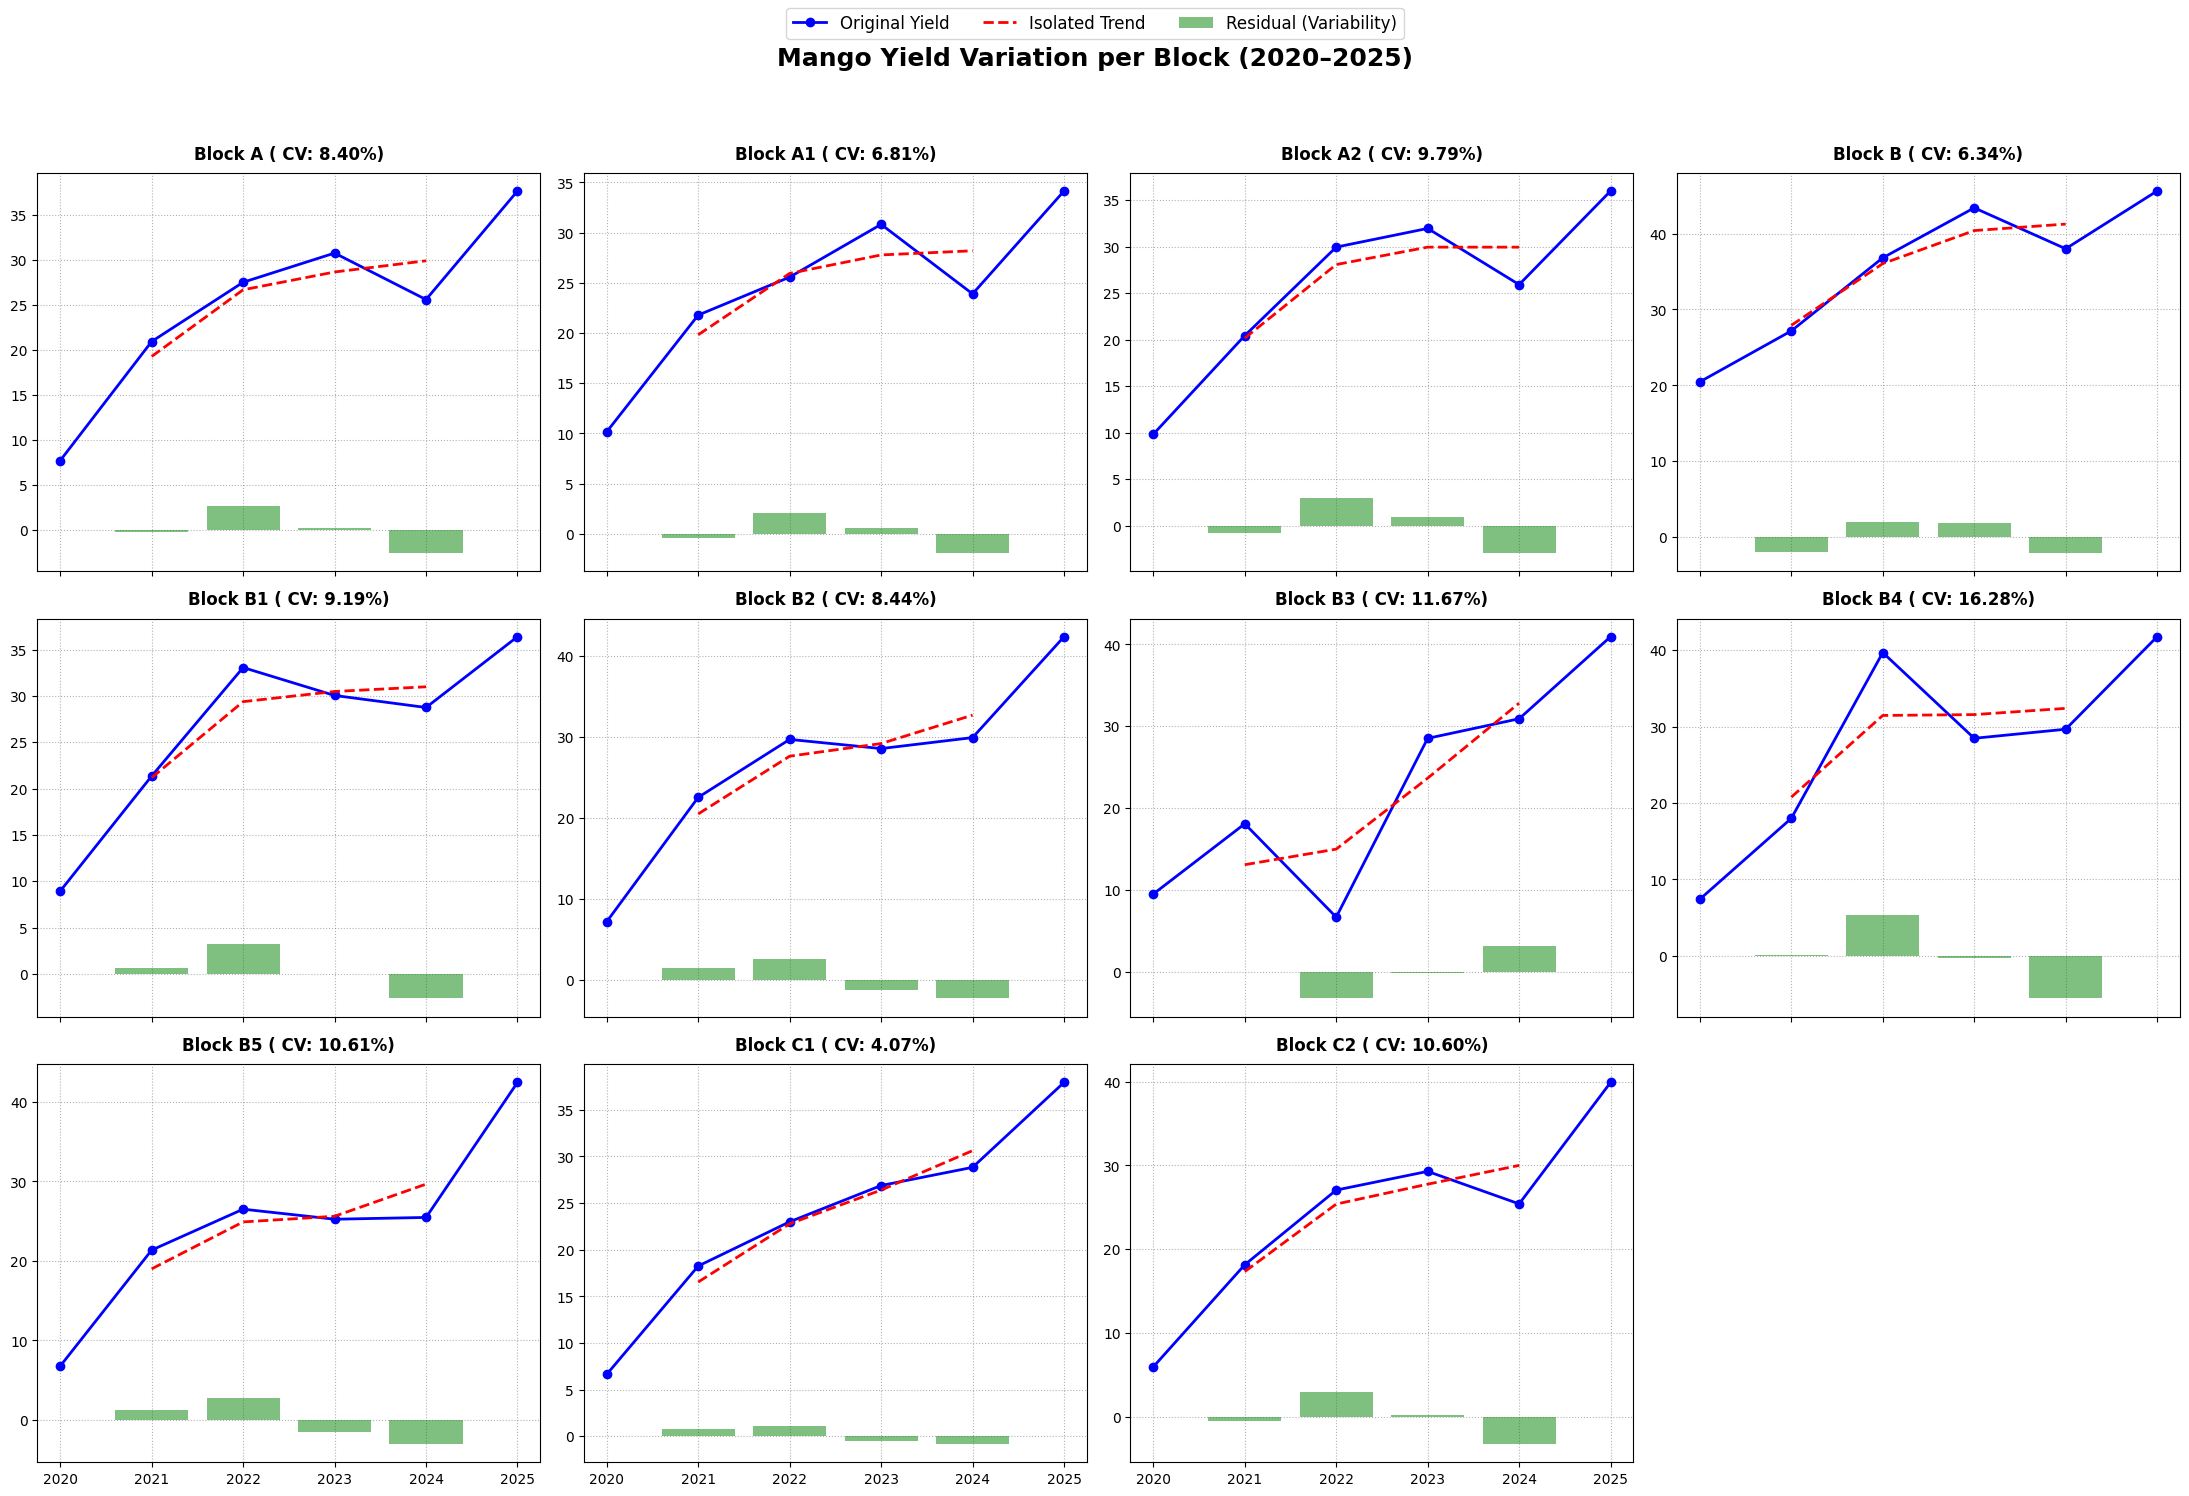


--- Final Yield Variability Analysis (Detrended) ---
Block  Raw_Variance  Detrended_Variance_(Residual)  Detrended_Volatility_(CV_%)
    A      103.0344                         4.4334                       8.4048
   A1       69.4167                         2.7631                       6.8131
   A2       88.6437                         6.3234                       9.7890
    B       93.4975                         4.9942                       6.3409
   B1       98.7385                         5.8964                       9.1902
   B2      132.6152                         5.0771                       8.4399
   B3      177.5628                         6.8515                      11.6706
   B4      170.1605                        20.0178                      16.2776
   B5      130.2611                         6.8310                      10.6117
   C1      112.0502                         0.9216                       4.0687
   C2      130.4511                         6.6303                

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load Data
yield_data = pd.read_csv("/Block_Year_Yield.csv")

# Sort data to ensure chronological order per block
yield_data = yield_data.sort_values(['Block', 'Year'])

blocks = yield_data["Block"].unique()

# Dataframes to store our results
detrended_records = []
variability_results = []

# -----------------------------------------------------------------
# 🔄 Process Each Block Individually
# -----------------------------------------------------------------
for block in blocks:
    block_df = yield_data[yield_data["Block"] == block].copy()

    # Setting Year as a proper period index for statsmodels
    block_df.index = pd.PeriodIndex(block_df['Year'], freq='A')

    try:
        decomposition = seasonal_decompose(block_df['Yield'], model='additive', period=2)

        block_df['Trend'] = decomposition.trend
        block_df['Residual'] = decomposition.resid

        # Calculate CV (Coefficient of Variation) on residuals
        residual_std = block_df['Residual'].std()
        mean_yield = block_df['Yield'].mean()
        cv_residual = (residual_std / mean_yield) * 100 if mean_yield != 0 else 0

        # Store metrics along with the block
        block_df['Detrended_CV'] = cv_residual

        variability_results.append({
            "Block": block,
            "Raw_Variance": block_df['Yield'].var(),
            "Detrended_Variance_(Residual)": block_df['Residual'].var(),
            "Detrended_Volatility_(CV_%)": cv_residual
        })

        detrended_records.append(block_df)

    except Exception as e:
        print(f"Skipping Block {block} due to insufficient data points: {e}")

# Combine processed data back
df_detrended = pd.concat(detrended_records)
df_metrics = pd.DataFrame(variability_results)

# -----------------------------------------------------------------
# 📊 Plotting the Polished Decomposed Results
# -----------------------------------------------------------------
cols = 4
rows = (len(blocks) // cols) + (len(blocks) % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(22, 15), sharex=True)
axes = axes.flatten()

for i, block in enumerate(blocks):
    ax = axes[i]
    block_data = df_detrended[df_detrended["Block"] == block]

    # Extract CV value for the current block label
    current_cv = block_data['Detrended_CV'].iloc[0]

    # Plot Original Yield (BLUE) vs Isolated Trend (RED)
    ax.plot(block_data["Year"], block_data["Yield"], marker='o', label="Original Yield", color='blue', linewidth=2)
    ax.plot(block_data["Year"], block_data["Trend"], linestyle='--', label="Isolated Trend", color='red', linewidth=2)

    # Plot Residuals (GREEN) as a bar chart at the bottom baseline
    ax.bar(block_data["Year"], block_data["Residual"], alpha=0.5, label="Residual (Variability)", color='green')

    # Title showing Block name and its calculated Detrended Volatility
    ax.set_title(f"Block {block} ( CV: {current_cv:.2f}%)", fontsize=12, pad=10, weight='semibold')

    # Add crisp gridlines
    ax.grid(True, which='both', linestyle=':', alpha=0.6, color='gray')
    ax.set_axisbelow(True) # Keeps grid lines behind data layers

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing globally to stop overlapping text boundaries
plt.subplots_adjust(hspace=0.5, wspace=0.25)

# Place unified clean legend in upper-middle area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=12, frameon=True)

plt.suptitle("Mango Yield Variation per Block (2020–2025)", fontsize=18, weight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save high-resolution output for slides/document
plt.savefig("polished_detrended_yield.png", dpi=300)
from google.colab import files
files.download("polished_detrended_yield.png")
plt.show()

# -----------------------------------------------------------------
# 📈 Summary Text Output
# -----------------------------------------------------------------
print("\n--- Final Yield Variability Analysis (Detrended) ---")
print(df_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

In [ ]:
block_variability = yield_data.groupby("Block")["Yield"].agg(["mean", "std"]).reset_index()

block_variability["CV (%)"] = (block_variability["std"] / block_variability["mean"]) * 100

In [ ]:
def classify_variation(cv):
    if cv < 10:
        return "Low"
    elif cv < 20:
        return "Moderate"
    else:
        return "High"

block_variability["Variability"] = block_variability["CV (%)"].apply(classify_variation)

print(block_variability)

# Export to CSV
block_variability.to_csv("block_variability_classified.csv", index=False)

   Block       mean        std     CV (%) Variability
0      A  25.052000  10.150585  40.518064        High
1     A1  24.398000   8.331669  34.148982        High
2     A2  25.688278   9.415078  36.651262        High
3      B  35.243833   9.669412  27.435756        High
4     B1  26.422111   9.936725  37.607613        High
5     B2  26.697611  11.515868  43.134452        High
6     B3  22.428389  13.325269  59.412509        High
7     B4  27.486389  13.044559  47.458250        High
8     B5  24.629556  11.413200  46.339449        High
9     C1  23.595056  10.585379  44.862699        High
10    C2  24.300500  11.421519  47.001168        High


<Figure size 800x500 with 0 Axes>

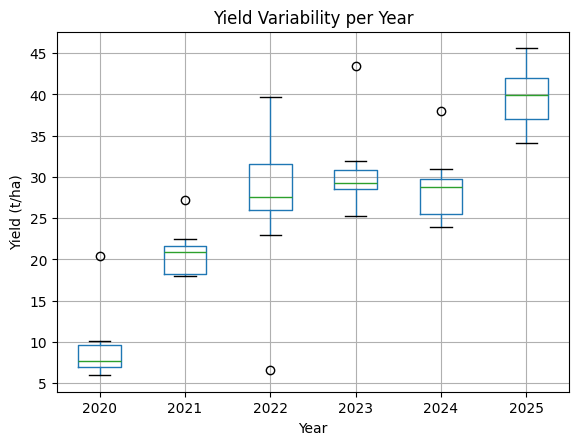


Yield Statistics Table
      count       mean       std        min        25%        50%        75%  \
Year                                                                           
2020   11.0   9.147667  4.007106   5.955333   6.999167   7.738333   9.653500   
2021   11.0  20.733091  2.725405  17.985667  18.203333  20.960000  21.573000   
2022   11.0  27.772515  8.576584   6.649667  26.036000  27.539000  31.512667   
2023   11.0  30.359091  4.719001  25.238333  28.486833  29.296667  30.799667   
2024   11.0  28.396667  3.927445  23.898333  25.541500  28.749667  29.769333   
2025   11.0  39.559182  3.430173  34.144000  37.033500  39.922000  42.034500   

            max       IQR  
Year                       
2020  20.466667  2.654333  
2021  27.177667  3.369667  
2022  39.672333  5.476667  
2023  43.393333  2.312833  
2024  38.002000  4.227833  
2025  45.616667  5.001000  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- D. Yield Variability (Boxplot) ----
plt.figure(figsize=(8,5))
yield_data.boxplot(column="Yield", by="Year")

plt.xlabel("Year")
plt.ylabel("Yield (t/ha)")
plt.title("Yield Variability per Year")
plt.suptitle("")
plt.show()


# ---- E. Generate Summary Statistics Table ----
yield_summary = yield_data.groupby("Year")["Yield"].describe()

# Add additional useful statistics
yield_summary["IQR"] = yield_summary["75%"] - yield_summary["25%"]

print("\nYield Statistics Table")
print(yield_summary)


# ---- Optional: Export Table ----
yield_summary.to_csv("yield_variability_statistics.csv")